In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer

# Preprocessing
from sklearn.preprocessing import LabelEncoder

In [2]:
# Load CSV file
df = pd.read_csv("mma_data_fightmetric.csv")

# View dataset
df.head()

,Event,Date,Fight Number,Division,Weightclass,Fighter,Opponent,Result,Method,Round,Time,Sig Strikes,Takedowns,Sub Attempts,Guard Passes,Url
0,UFC Fight Night: Lawler vs. Dos Anjos,2017-12-16,0,Welterweight,170,Rafael Dos Anjos,Robbie Lawler,win,U-DEC,5,5:00,172,2,0,1,http://www.fightmetric.com/event-details/eaa0a...
1,UFC Fight Night: Lawler vs. Dos Anjos,2017-12-16,0,Welterweight,170,Robbie Lawler,Rafael Dos Anjos,loss,U-DEC,5,5:00,86,0,0,0,http://www.fightmetric.com/event-details/eaa0a...
2,UFC Fight Night: Lawler vs. Dos Anjos,2017-12-16,1,Featherweight,145,Josh Emmett,Ricardo Lamas,win,KO/TKO Punch,1,4:33,10,0,0,0,http://www.fightmetric.com/event-details/eaa0a...
3,UFC Fight Night: Lawler vs. Dos Anjos,2017-12-16,1,Featherweight,145,Ricardo Lamas,Josh Emmett,loss,KO/TKO Punch,1,4:33,17,0,0,0,http://www.fightmetric.com/event-details/eaa0a...
4,UFC Fight Night: Lawler vs. Dos Anjos,2017-12-16,2,Welterweight,170,Santiago Ponzinibbio,Mike Perry,win,U-DEC,3,5:00,78,3,0,2,http://www.fightmetric.com/event-details/eaa0a...


In [3]:
# Check dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8938 entries, 0 to 8937
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Event         8938 non-null   str  
 1   Date          8938 non-null   str  
 2   Fight Number  8938 non-null   int64
 3   Division      8938 non-null   str  
 4   Weightclass   8938 non-null   int64
 5   Fighter       8938 non-null   str  
 6   Opponent      8938 non-null   str  
 7   Result        8938 non-null   str  
 8   Method        8938 non-null   str  
 9   Round         8938 non-null   int64
 10  Time          8938 non-null   str  
 11  Sig Strikes   8938 non-null   str  
 12  Takedowns     8938 non-null   str  
 13  Sub Attempts  8938 non-null   str  
 14  Guard Passes  8938 non-null   str  
 15  Url           8938 non-null   str  
dtypes: int64(3), str(13)
memory usage: 2.4 MB


In [4]:
# Check missing values
df.isnull().sum()

Event           0
Date            0
Fight Number    0
Division        0
Weightclass     0
Fighter         0
Opponent        0
Result          0
Method          0
Round           0
Time            0
Sig Strikes     0
Takedowns       0
Sub Attempts    0
Guard Passes    0
Url             0
dtype: int64

In [5]:
# Fill missing text values
df.fillna("Unknown", inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

In [7]:
print(df.columns)

Index(['Event', 'Date', 'Fight Number', 'Division', 'Weightclass', 'Fighter',
       'Opponent', 'Result', 'Method', 'Round', 'Time', 'Sig Strikes',
       'Takedowns', 'Sub Attempts', 'Guard Passes', 'Url'],
      dtype='str')


In [9]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Event', 'Date', 'Fight Number', 'Division', 'Weightclass', 'Fighter',
       'Opponent', 'Result', 'Method', 'Round', 'Time', 'Sig Strikes',
       'Takedowns', 'Sub Attempts', 'Guard Passes', 'Url'],
      dtype='str')


In [11]:
df.columns.tolist()

['Event',
 'Date',
 'Fight Number',
 'Division',
 'Weightclass',
 'Fighter',
 'Opponent',
 'Result',
 'Method',
 'Round',
 'Time',
 'Sig Strikes',
 'Takedowns',
 'Sub Attempts',
 'Guard Passes',
 'Url']

In [13]:
from sklearn.model_selection import train_test_split
import numpy as np

X = np.array([[1,2],[3,4],[5,6],[7,8]])
y = np.array([0,1,0,1])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [17]:
# Import libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Predict on test data
dt_pred = dt_model.predict(X_test)

# Print accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

# Print classification report
print("\nClassification Report:\n")
print(classification_report(y_test, dt_pred, zero_division=0))

Decision Tree Accuracy: 0.0

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



In [18]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

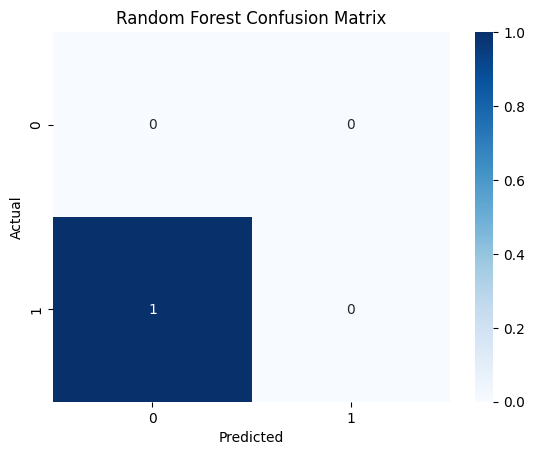

In [19]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

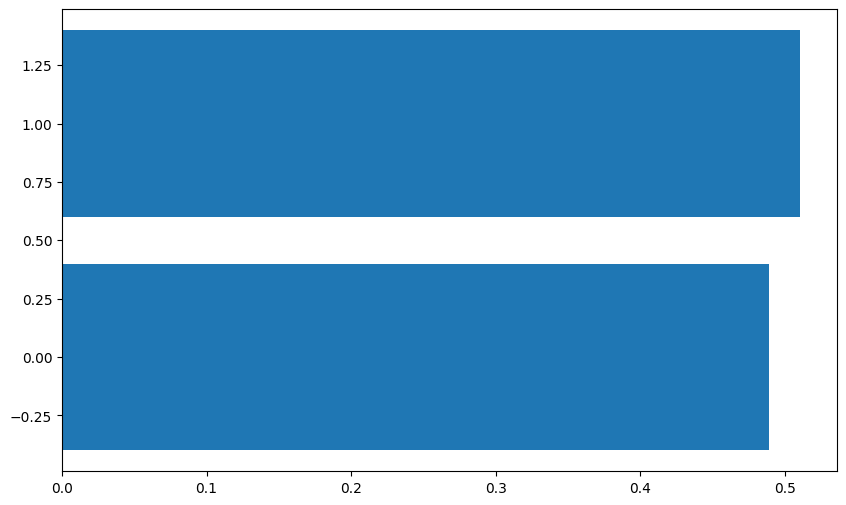

In [20]:
importances = rf_model.feature_importances_

indices = np.argsort(importances)[-15:]

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)),
         importances[indices])

plt.yticks(range(len(indices)),
           X.columns[indices])

plt.title("Top 15 Important Features")
plt.show()

In [22]:
import pandas as pd

X_test_df = pd.DataFrame(X_test)

sample = X_test_df.iloc[0:1]

prediction = rf_model.predict(sample)

print("Predicted Winner Class:", prediction)

Predicted Winner Class: [0]
